# 06 · Evaluation & Backtesting — Metrics, Time-Series CV, Walk-Forward, Conformal

## Part 6 — Evaluation & Backtesting

Five families of models (Parts 3–5) all claim a number. This notebook is the referee. Good
evaluation is what separates a model that *looks* good on one slice from one that actually works.

| # | tool | what it protects against |
|---|---|---|
| 1 | **The metric zoo** | picking a metric that lies (MAPE near zero, scale traps) |
| 2–3 | **Time-series cross-validation** | judging on a single lucky/unlucky window; leakage from shuffling |
| 4–5 | **Walk-forward backtesting** | overstating accuracy; not testing the *refit-and-roll* reality |
| 6 | **Conformal intervals** | false confidence — a point forecast with no honest uncertainty |

Everything runs on **CO₂**, so the numbers connect directly to Parts 3 & 5.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd()
ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

import lightgbm as lgb
from src import backtest as bt, forecasting as fc, ml_forecast as mlf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.datasets import co2

co2m = co2.load_pandas().data["co2"].resample("MS").mean().interpolate()
LGBM = dict(n_estimators=200, num_leaves=31, learning_rate=0.05, min_child_samples=10,
            random_state=0, verbose=-1)

# Forecaster adapters: each takes (train_series, horizon) -> array of predictions.
def f_seasonal_naive(tr, h): return fc.baseline_forecasts(tr, h, 12)["seasonal_naive"]
def f_holt_winters(tr, h):
    return ExponentialSmoothing(tr, trend="add", seasonal="add", seasonal_periods=12).fit().forecast(h).values
def f_lgbm_diff(tr, h):
    d = tr.diff().dropna(); sup = mlf.make_supervised(d, n_lags=12); cols = mlf.feature_cols(sup)
    m = lgb.LGBMRegressor(**LGBM).fit(sup[cols], sup["y"])
    return mlf.reconstruct_from_diff(mlf.recursive_forecast(m, d, h, cols), tr.iloc[-1]).values
print("CO2:", len(co2m), "months |", co2m.index.min().date(), "->", co2m.index.max().date())


setup ok | numpy 2.1.3 | pandas 2.3.3


CO2: 526 months | 1958-03-01 -> 2001-12-01


### 1. The metric zoo — and how each one lies

| metric | formula idea | strengths | fails when |
|---|---|---|---|
| **MAE** | mean &#124;error&#124; | robust, same units | can't compare across scales |
| **RMSE** | √mean(error²) | penalises big misses | outlier-sensitive; scale-bound |
| **MAPE** | mean &#124;error/actual&#124; | intuitive % | **explodes near 0**; punishes over- vs under- asymmetrically |
| **sMAPE** | symmetric % | bounded | still odd near 0 |
| **WAPE** | Σ&#124;error&#124; / Σ&#124;actual&#124; | %-scaled but **robust to zeros** (aggregate first) | hides per-point error |
| **MASE** | MAE ÷ in-sample naive MAE | **scale-free, comparable, baseline-relative** (<1 beats naive) | needs a sensible seasonal period |

**Default to MASE** for choosing models and **WAPE** for a business-readable %. For *probabilistic*
forecasts use the **pinball (quantile) loss** or **CRPS**. Here is MAPE blowing up where WAPE stays
sane — a series with one near-zero actual:

In [2]:
y_true = np.array([100., 50., 1., 80.]); y_pred = np.array([110., 55., 3., 85.])
m = fc.forecast_metrics(y_true, y_pred, y_true, m=1)
print("MAPE = %.1f%%   <- the single '1' actual dominates (|2/1| = 200%% error)" % m["MAPE%"])
print("WAPE = %.1f%%   <- aggregates first, so the tiny denominator can't hijack it" % m["WAPE%"])
print("\nSame errors, wildly different verdicts. The metric is a modelling choice, not an afterthought.")

MAPE = 56.6%   <- the single '1' actual dominates (|2/1| = 200% error)
WAPE = 9.5%   <- aggregates first, so the tiny denominator can't hijack it

Same errors, wildly different verdicts. The metric is a modelling choice, not an afterthought.


### 2. Why a single train/test split lies

Parts 3 & 5 held out the *last 24 months*. That is **one draw**. Had we picked a different window
— a calmer or a more volatile stretch — the ranking could flip. A point estimate of accuracy has a
variance, and a single split hides it. The fix is to evaluate over **many** time-ordered windows.

### 3. Time-series cross-validation — never shuffle

Ordinary k-fold CV **shuffles**, which lets the model train on the future to predict the past —
catastrophic leakage. Time-series CV keeps order, with two schemes:

- **Expanding** window — training set grows from the start (use all history).
- **Sliding** window — fixed-width training set rolls forward (adapts to regime change, constant cost).

For extra safety with engineered lags, insert a **gap / embargo** between train and test so a
rolling feature can't straddle the boundary.

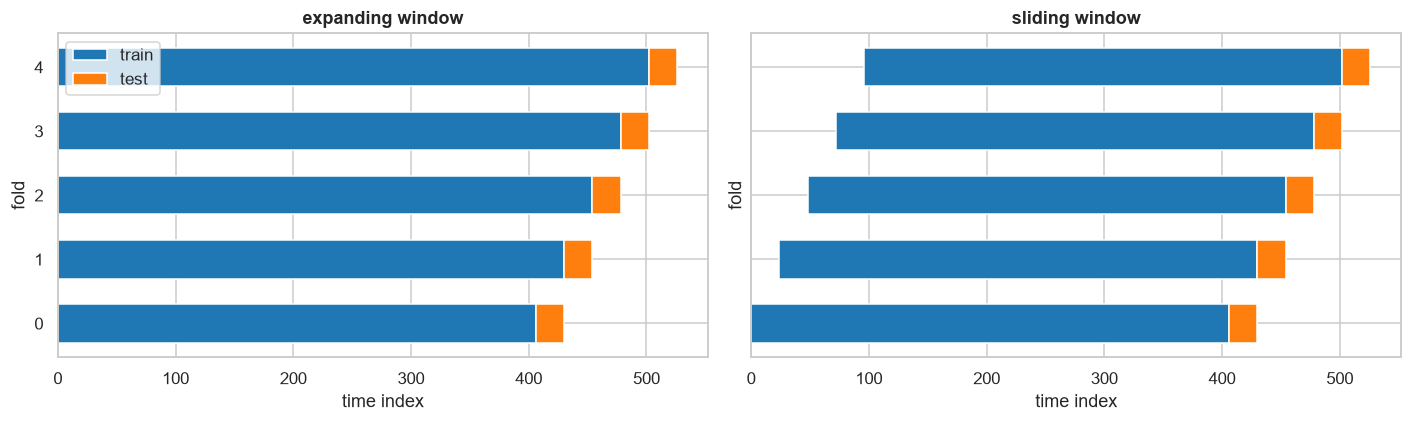

Each row is a fold: blue = train (in the past), orange = test (in the future). Order is never broken.


In [3]:
fig = bt.plot_cv(n=len(co2m), n_splits=5, horizon=24, fname="p6_cv_schemes.png")
plt.show()
print("Each row is a fold: blue = train (in the past), orange = test (in the future). Order is never broken.")

### 4. Walk-forward backtesting — the way it actually runs

The gold standard: start with an initial history, **forecast one step, reveal the truth, refit,
step forward** — repeating to the end. This mimics production exactly and yields a whole
out-of-sample track record instead of a single window. We backtest three models from Parts 3 & 5
with **126 one-step refits**:

In [4]:
initial = 400
backtests = {}
for name, f in [("seasonal_naive", f_seasonal_naive), ("Holt-Winters", f_holt_winters), ("LGBM-diff", f_lgbm_diff)]:
    backtests[name] = bt.walk_forward(co2m, f, initial=initial, horizon=1, step=1)
folds = len(backtests["Holt-Winters"])
rows = {name: fc.forecast_metrics(co2m.loc[p.index].values, p.values, co2m.iloc[:initial].values, 12)
        for name, p in backtests.items()}
board = pd.DataFrame(rows).T.sort_values("MASE").round(4)
print(f"Walk-forward one-step backtest over {folds} folds:")
print(board.to_string())

Walk-forward one-step backtest over 126 folds:
                   MAE    RMSE   MAPE%  sMAPE%   WAPE%    MASE
Holt-Winters    0.2410  0.3077  0.0665  0.0665  0.0664  0.1958
LGBM-diff       0.2691  0.3373  0.0740  0.0740  0.0741  0.2185
seasonal_naive  1.5088  1.6792  0.4149  0.4160  0.4157  1.2255


This is a **far more trustworthy** verdict than one split: Holt-Winters wins across 126
windows (MASE ≈ 0.20), with LGBM-diff a close second — the single-split ranking from Part 5 holds
up under stress. seasonal-naive (MASE > 1) is the bar they clear. *Now* we can trust the ranking.

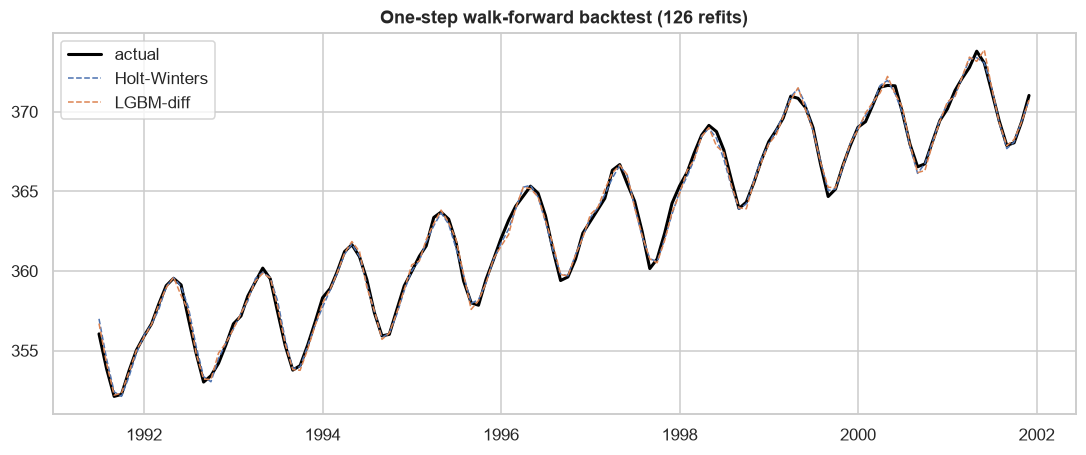

In [5]:
# Visualise the one-step backtest tracks over the out-of-sample region.
fig, ax = plt.subplots(figsize=(12, 4.5))
oos = backtests["Holt-Winters"].index
ax.plot(oos, co2m.loc[oos].values, color="black", lw=2, label="actual")
for name in ["Holt-Winters", "LGBM-diff"]:
    ax.plot(oos, backtests[name].values, lw=1, ls="--", label=name)
ax.set_title(f"One-step walk-forward backtest ({folds} refits)"); ax.legend()
eda.savefig(fig, "p6_backtest.png"); plt.show()

### 6. Conformal prediction intervals — honest uncertainty

A point forecast hides risk. A good interval should **contain the truth (1−α)% of the time**.
Model-based intervals (Part 3) assume the model's error distribution is right; **conformal**
prediction drops that assumption and gives a **distribution-free coverage guarantee** from data
alone:

1. Collect residuals on a held-out **calibration** set (here: the first half of the backtest).
2. Take the **(1−α) quantile of |residual|** as the radius `q`.
3. The interval `forecast ± q` then covers ≈ (1−α) of future points — *whatever* the error shape.

We calibrate on the first 63 backtest residuals and test coverage on the next 63:

conformal 90% interval -> radius q=0.552, width=1.10, EMPIRICAL coverage=93.7% (target 90%)


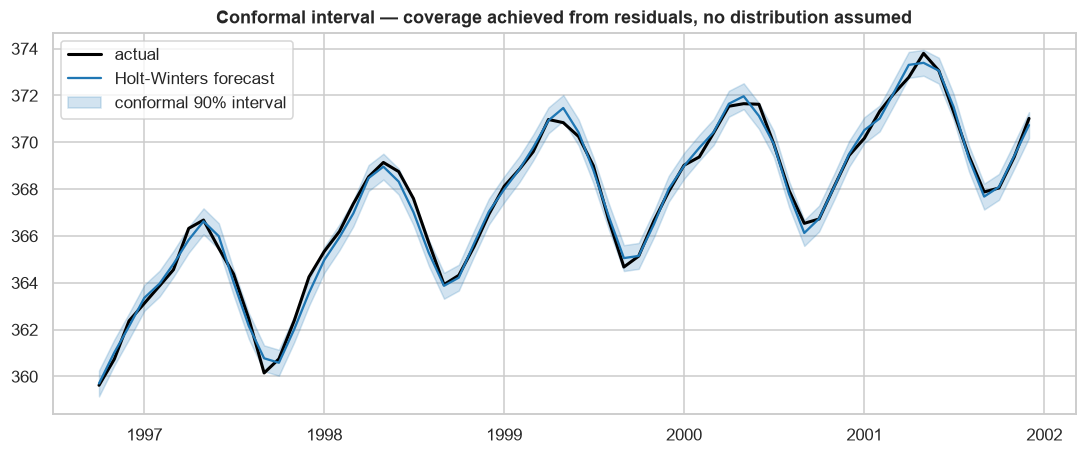

In [6]:
hw_pred = backtests["Holt-Winters"]; hw_act = co2m.loc[hw_pred.index]
resid = (hw_act - hw_pred).values
half = len(resid) // 2
q = bt.conformal_q(resid[:half], alpha=0.10)
ev = hw_pred.index[half:]
lo, hi = hw_pred.values[half:] - q, hw_pred.values[half:] + q
cov = bt.coverage(hw_act.values[half:], lo, hi)
print("conformal 90%% interval -> radius q=%.3f, width=%.2f, EMPIRICAL coverage=%.1f%% (target 90%%)" % (q, 2*q, 100*cov))
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(ev, hw_act.values[half:], color="black", lw=2, label="actual")
ax.plot(ev, hw_pred.values[half:], color="tab:blue", lw=1.5, label="Holt-Winters forecast")
ax.fill_between(ev, lo, hi, color="tab:blue", alpha=0.2, label="conformal 90% interval")
ax.set_title("Conformal interval — coverage achieved from residuals, no distribution assumed"); ax.legend()
eda.savefig(fig, "p6_conformal.png"); plt.show()

Coverage lands near the **90% target** without assuming Gaussian errors — exactly the promise
of conformal prediction. (For time series with drifting volatility, the production-grade versions are
**adaptive**: EnbPI and ACI widen/narrow the band as conditions change.)

### 7. The acid test — does it survive on S&P 500 returns?

Backtesting's most valuable job is killing false discoveries. On near-random equity returns
(Parts 2–3), a rigorous walk-forward should confirm that **no model meaningfully beats the trivial
baselines** — protecting you from a model that looked clever on one lucky window.

In [7]:
from src import data
ret = data.clean_shiller()["return"].dropna()
def f_naive(tr,h): return fc.baseline_forecasts(tr,h,1)["naive"]
def f_mean(tr,h):  return fc.baseline_forecasts(tr,h,1)["mean"]
def f_arima(tr,h): return SARIMAX(tr, order=(1,0,1)).fit(disp=False).forecast(h).values
bt_ret = {n: bt.walk_forward(ret, f, initial=len(ret)-60, horizon=1, step=1) for n,f in
          [("naive",f_naive),("mean",f_mean),("ARIMA(1,0,1)",f_arima)]}
rows = {n: fc.forecast_metrics(ret.loc[p.index].values, p.values, ret.iloc[:len(ret)-60].values, 1)
        for n,p in bt_ret.items()}
tbl = pd.DataFrame(rows).T[["MAE","WAPE%","MASE"]].sort_values("MASE").round(4)
print(tbl.to_string())
spread = tbl["MASE"].max() - tbl["MASE"].min()
print(f"\nAll three sit within {spread:.2f} MASE of each other -- ARIMA's hair-thin edge over the")
print("mean is noise, not a signal. Backtesting confirms Part 3: returns are ~unforecastable.")

C:\Users\parth\practice-eda\sp500-shiller\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\parth\practice-eda\sp500-shiller\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                 MAE     WAPE%    MASE
ARIMA(1,0,1)  0.0272   94.1124  0.7903
mean          0.0277   95.7258  0.8038
naive         0.0334  115.4935  0.9698

All three sit within 0.18 MASE of each other -- ARIMA's hair-thin edge over the
mean is noise, not a signal. Backtesting confirms Part 3: returns are ~unforecastable.


### 8. Course capstone — the end-to-end workflow

Across the six parts, the through-line is a single disciplined pipeline:

1. **Look first (Part 1).** Distributions, fat tails, outliers, correlation/MI, VIF, categorical
   association, and the **missingness mechanism** — before any model.
2. **Make it stationary & understand it (Part 2).** Index hygiene, decomposition, **ADF×KPSS**,
   ACF/PACF, volatility clustering. *Model returns, not prices.*
3. **Forecast univariately (Part 3).** Baseline → ETS → ARIMA/SARIMA, validated by Box–Jenkins.
4. **Go multivariate (Part 4).** PCA market factor, VAR/Granger, **cointegration & pairs**.
5. **Bring in ML (Part 5).** Supervised reframing, leakage discipline, trees + the differencing
   fix — and the humility that ML isn't always better.
6. **Judge honestly (Part 6).** The right metric (**MASE/WAPE**), **walk-forward** backtesting,
   and **conformal** intervals.

**The recurring lessons, distilled:**
- *Always beat the naive baseline* — most of the value is there; everything else is incremental.
- *Stationarity is the hinge* — for tests, for ARIMA's `d`, even for whether trees can extrapolate.
- *Leakage is the silent killer* — shuffle, an unshifted rolling window, or a peeked-at future, and
  your numbers are fiction.
- *Markets humble models* — returns are near-unforecastable; the predictable thing is **risk**.
- *Evaluation is a first-class design decision*, not a final formality.

### Takeaways

- **Choose the metric deliberately**: MASE to compare, WAPE for a robust %, pinball/CRPS for
  probabilistic. MAPE lies near zero.
- A **single split is one sample** — use **time-ordered CV** (expanding/sliding, never shuffled).
- **Walk-forward backtesting** (refit-and-roll) is the production-faithful gold standard; it
  confirmed Holt-Winters > LightGBM on CO₂ and naive ≈ best on S&P returns.
- **Conformal intervals** deliver target coverage with no distributional assumption.

*That completes the course — Parts 0 through 6. The repo is a runnable reference you can return to
or extend (e.g. a new dataset in a sibling folder under `practice-eda/`).*